Initialize a model using a pretrained VGG network and train all layers from the start without freezing any part of the base model.

In [1]:
import os
import shutil
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Data Loading, Balancing & Sampling 

In [2]:
# ------------------- Balance and Sample Data -------------------

def create_balanced_sample(input_dir, output_dir, samples_per_class=300):
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir)

    class_counts = defaultdict(int)

    for class_name in os.listdir(input_dir):
        class_path = os.path.join(input_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)
        selected = images[:samples_per_class]

        os.makedirs(os.path.join(output_dir, class_name), exist_ok=True)

        for img in selected:
            src = os.path.join(class_path, img)
            dst = os.path.join(output_dir, class_name, img)
            shutil.copyfile(src, dst)

        class_counts[class_name] = len(selected)

    return class_counts

# Sample data (adjust number of samples as needed)
train_counts = create_balanced_sample('./processed/train', './balanced/train', samples_per_class=300)
test_counts = create_balanced_sample('./processed/test', './balanced/test', samples_per_class=100)

Plot For class Distribution

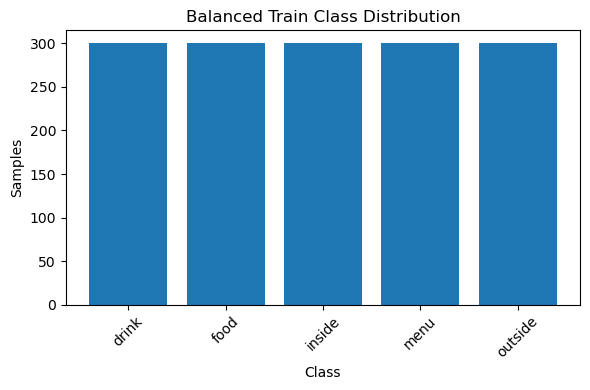

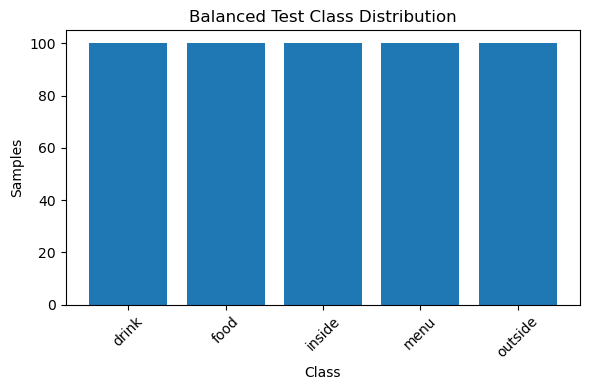

In [3]:
# ------------------- Plot Class Distribution -------------------

def plot_distribution(counts, title):
    classes = list(counts.keys())
    values = list(counts.values())
    plt.figure(figsize=(6, 4))
    plt.bar(classes, values)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Samples")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_distribution(train_counts, "Balanced Train Class Distribution")
plot_distribution(test_counts, "Balanced Test Class Distribution")

In [18]:
# ------------------- Load Data -------------------

train_dir = r"D:\balanced\train"
test_dir = r"D:\balanced\test"
img_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 1500 images belonging to 5 classes.
Found 500 images belonging to 5 classes.


Model Building 

In [19]:
# ------------------- Build Model (Train All Layers) -------------------

def build_vgg_model(input_shape=(224, 224, 3), num_classes=5):
    base_model = VGG16(include_top=False, weights='imagenet', input_shape=input_shape)
    
    # Train all layers
    for layer in base_model.layers:
        layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

model = build_vgg_model(num_classes=5)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 256)                 │         131,3

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 14,847,301 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

Model training 

In [21]:
# ------------------- Train Model -------------------

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy')
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=2,
    callbacks=callbacks
)

Epoch 1/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 594s 13s/step - accuracy: 0.2548 - loss: 1.6151 - val_accuracy: 0.3640 - val_loss: 1.4561
Epoch 2/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 579s 12s/step - accuracy: 0.3239 - loss: 1.4369 - val_accuracy: 0.4680 - val_loss: 1.3031


Plot for Confusion Matrix , ROC Curve & Train vs Val Accuracy-Loss 

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ------------------ Predict on Test Data ------------------
val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

16/16 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step


[[ 3 29 39 23  6]
 [ 3 28 33 34  2]
 [ 4 36 31 25  4]
 [ 1 26 33 33  7]
 [ 3 30 31 32  4]]


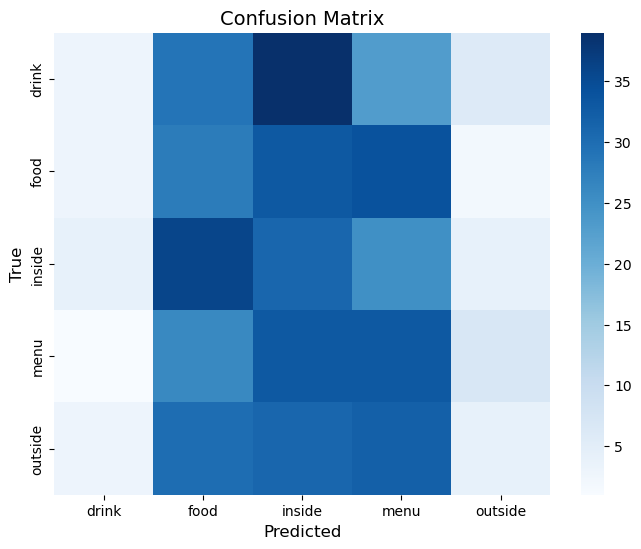

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm ,fmt="d", cmap="Blues",
                 xticklabels=class_names,
                 yticklabels=class_names)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)

print(cm)

plt.show()


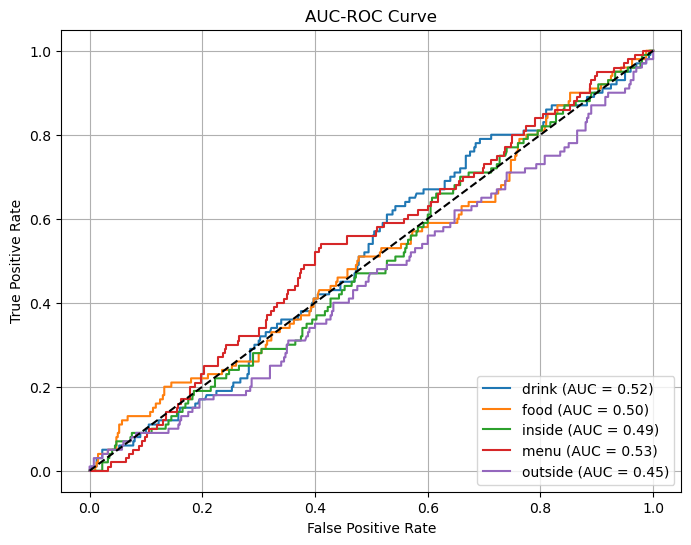

In [33]:
# ------------------ ROC Curve and AUC ------------------
# One-hot true labels for ROC
from sklearn.preprocessing import label_binarize
y_true_onehot = label_binarize(y_true, classes=list(range(len(class_names))))

plt.figure(figsize=(8, 6))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Overall AUC Score: 0.4997


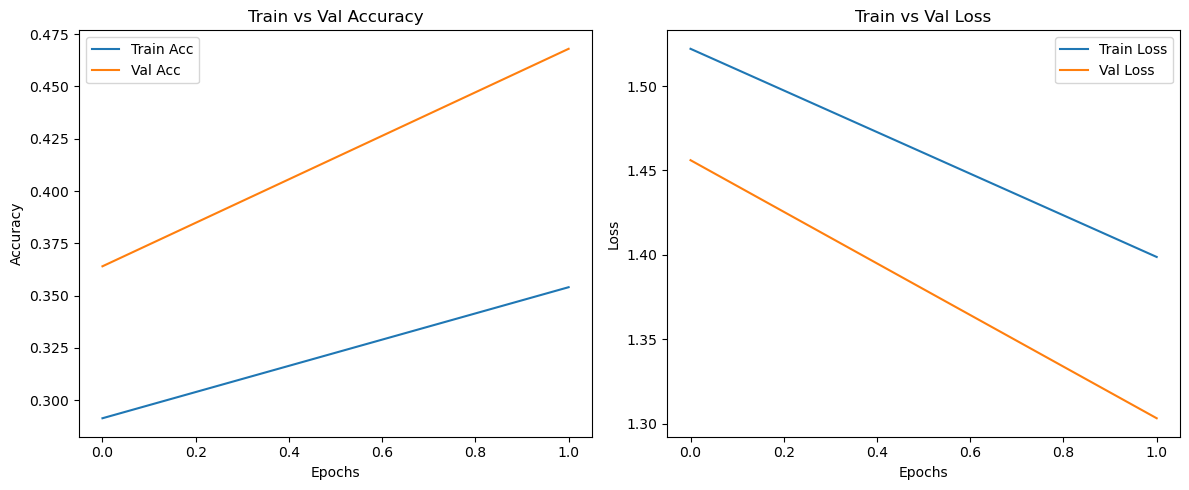

In [34]:
# ------------------ Overall AUC Score ------------------
from sklearn.metrics import roc_auc_score
overall_auc = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')
print(f"Overall AUC Score: {overall_auc:.4f}")

# ------------------ Accuracy and Loss Curves ------------------
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Train vs Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Train vs Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


Model Saving 

In [35]:
model.save("D:/vgg_base.keras")
print("saved")

saved
